In [1]:
%run header.ipynb

fs = 16000
N  = 1024
f0 = 50000/N
x  = np.sin(2*np.pi*(f0/fs)*(np.linspace(0,N-1,N)))
X  = fft(x)
f  = np.linspace(0,fs,N)
k  = np.linspace(0,N-1,N)




# The Discrete Fourier Transform

The frequency-domain representation gives insight into the composition of time series and hence of musical signals. In the digital domain we are formemost interested in discrete signals and will thus introduce the Discrete Fourier Transform (DFT). This section does not aim at a full introduction of the DFT, but illustrates a few aspects which help to better understand the basics of computer music and sound synthesis. 

The DFT $X[k]$ of a discrete signal $x$ with the length $N$ and the sampling frequency $f_s$ is calculated as follows. For every frequency bin $k=1 ... N, N \in \mathbb{N}$ of the output, the correlation of the signal with a complex oscillation with the frequency $2 \pi \frac{k}{N}$ is calculated:

$$
\begin{eqnarray}
X[k] & = & \sum\limits_{n=0}^{N-1} x[n] \left( \cos \left(2 \pi k \frac{n}{N}) -j \sin(2 \pi k \frac{n}{N} \right) \right)  \\
X[k] & = & \sum\limits_{n=0}^{N-1} x[n] e^{-j 2 \pi k \frac{n}{N}} 
\end{eqnarray}
$$

Since real and imaginary part of the complex oscillation have a relative phase of $\frac{\pi}{2}$, the correlation does not only deliver information on the magnitude of spectral components, but also on their phase. The real part is a cosine, whereas the imaginary part is a sine function. The following plot shows the real and imaginary component of the complex oscillations for the indices $k=1$ and $k=2$:

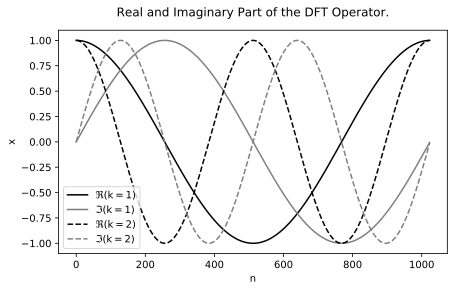

In [2]:
plt.figure()

real = np.cos(2*np.pi*(1/N)*k)
imag = np.sin(2*np.pi*(1/N)*k)
p1 = plt.plot(real,'k')
p2 = plt.plot(imag,'grey')

real = np.cos(2*np.pi*(2/N)*k)
imag = np.sin(2*np.pi*(2/N)*k)
p1 = plt.plot(real,'k', linestyle='dashed')
p2 = plt.plot(imag,'gray', linestyle='dashed')

plt.suptitle("Real and Imaginary Part of the DFT Operator.");
plt.xlabel("$n$");
plt.ylabel("$x$");

plt.legend([
    '$\\Re(k=1)$',
    '$\\Im(k=1)$',
    '$\\Re(k=2)$',
    '$\\Im(k=2)$']);

---

## Absolute Representation

In many cases, the absolute values of DFT spectra will be shown only for the positive frequencies. This representation is used in most examples in the following sections. The sine wave becomes a single peak at its frequency:

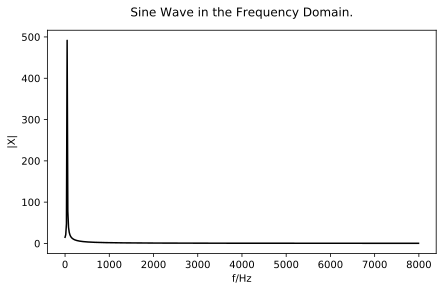

In [6]:

plt.figure()
plt.suptitle("Sine Wave in the Frequency Domain.");
p1 = plt.plot(f[0:round(N/2)],abs(X[0:round(N/2)]),'k')
plt.xlabel("$f/Hz$");
plt.ylabel("$|X|$");

----

## DFT Support Points 

For a DFT with $N$ points and a sampling rate $f_s$, 
the DFT bins $b[k]$ - or support points - are located at the following frequencies:

$$
b[k] = k \frac{f_s}{N}
$$

Only for harmonic signals located at these exact frequencies,
the DFT results can be expressed by the Dirac-Delta function.

# Links

This website visualizes the DFT very nicely for a better understanding:
https://jackschaedler.github.io/circles-sines-signals/dft_walkthrough.html


